# Clasificador de Intención — Multi-agente de Accesibilidad

Notebook de entrenamiento para la Fase 3 de la mini-tesis.

**Pregunta de investigación:** ¿Qué aporta cambiar la representación de TF-IDF a embeddings multilingües (MiniLM), manteniendo el mismo clasificador (Logistic Regression)?

**Diseño:** misma cabeza, distinto representador → el resultado aísla el aporte de la representación.

Al final se guarda el mejor modelo (por F1 macro) en `../modelo.joblib`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import joblib

## Sección 2: Carga y exploración del dataset

In [2]:
df = pd.read_csv('../data/intents/dataset.csv')
print(f'Total de frases: {len(df)}')

# Lista ordenada de intenciones; se reutiliza en matrices de confusión y gráficos
INTENCIONES = sorted(df['intent'].unique())

# Etiquetas cortas para que no se solapen en los ejes de los gráficos
ETIQUETAS_CORTAS = [e.split('_')[0] for e in INTENCIONES]

df.head()

Total de frases: 415


,intent,text
0,MEDICATION_HEALTH,Oye mijito ¿ya me toca tomar la pastillita del...
1,MEDICATION_HEALTH,¿A qué hora me corresponde el jarabe que me re...
2,MEDICATION_HEALTH,Tengo un dolorcito en la rodilla desde ayer ¿s...
3,FAMILY_COMMUNICATION,Quiero mandarle un mensajito a mi hijo Carlos ...
4,FAMILY_COMMUNICATION,¿Puedes avisarle a mi hija María que ya tomé l...


intent
EMERGENCY               83
FAMILY_COMMUNICATION    83
MEDICATION_HEALTH       83
RECIPE_MULTIMEDIA       83
SMALL_TALK              83


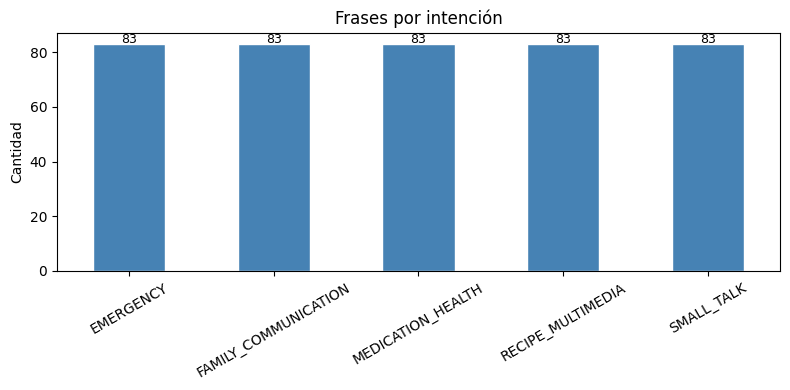

In [3]:
conteo = df['intent'].value_counts().sort_index()
print(conteo.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
conteo.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Frases por intención')
ax.set_ylabel('Cantidad')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
for barra in ax.patches:
    ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.5,
            str(int(barra.get_height())), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

C:\Users\Manuel Pillapa\AppData\Local\Temp\ipykernel_31980\3186581260.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos_longitud, labels=ETIQUETAS_CORTAS)


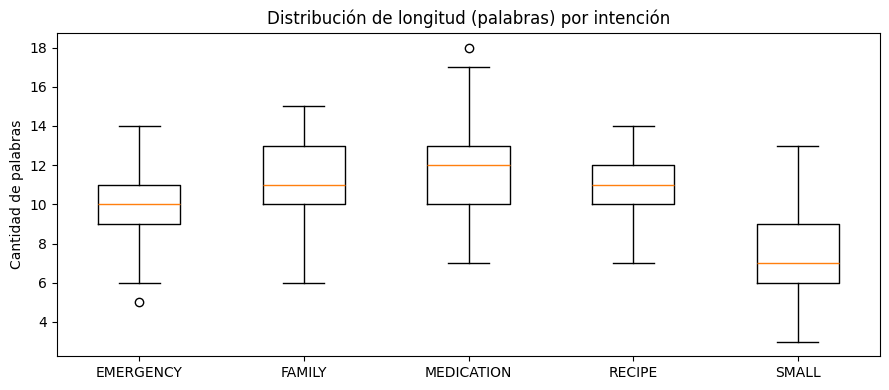

In [4]:
df['longitud'] = df['text'].str.split().str.len()
datos_longitud = [df[df['intent'] == i]['longitud'].values for i in INTENCIONES]

fig, ax = plt.subplots(figsize=(9, 4))
ax.boxplot(datos_longitud, labels=ETIQUETAS_CORTAS)
ax.set_title('Distribución de longitud (palabras) por intención')
ax.set_ylabel('Cantidad de palabras')
plt.tight_layout()
plt.show()

In [6]:
for intencion in INTENCIONES:
    print()
    print(f'{intencion}')
    muestra = df[df['intent'] == intencion]['text'].sample(3, random_state=42)
    for texto in muestra:
        print(f'  • {texto}')


EMERGENCY
  • Necesito que vengan ya me está pasando algo
  • Me caí en el baño y no me puedo levantar ayúdame por favor
  • Me siento muy mal el corazón late rápido y me falta el aire

FAMILY_COMMUNICATION
  • Marca a mi sobrina que hace meses no hablo con ella
  • Quiero mandarle un mensajito a mi hijo Carlos que está en Quito
  • ¿Hay algún aviso de la familia que deba saber?

MEDICATION_HEALTH
  • Siempre me confundo ¿son dos comprimidos blancos o uno blanco y uno amarillo?
  • Oye mijito ¿ya me toca tomar la pastillita del corazón?
  • Listo ya me tomé el calmante ¿lo registras?

RECIPE_MULTIMEDIA
  • Espera espera ¿me repites lo del refrito que no entendí?
  • ¿Me lees la receta del locro de papas pasito a pasito?
  • Dice una libra de carne ¿eso cuánto es en gramos más o menos?

SMALL_TALK
  • ¿Puedes hacer cualquier cosa o tienes límites?
  • Buenos días mijito ¿cómo amaneciste hoy?
  • Oye hace tanto viento que la ventana no para de sonar


### EDA — Word Cloud y palabras frecuentes

El dominio es texto coloquial ecuatoriano. Visualizamos las palabras que dominan el corpus y si hay solapamiento de vocabulario entre intenciones — lo que anticiparía dificultades para el clasificador basado en n-gramas (TF-IDF).

**Nota:** requiere `pip install wordcloud` si no está instalado.

In [ ]:

# !pip install wordcloud -q   ← descomentar si no está instalado

from wordcloud import WordCloud
from collections import Counter
import re

STOPWORDS_ES = {
    'de', 'que', 'el', 'la', 'en', 'es', 'me', 'mi', 'te', 'le', 'se',
    'un', 'una', 'los', 'las', 'al', 'del', 'ya', 'no', 'si', 'por',
    'con', 'para', 'como', 'hay', 'lo', 'su', 'tu', 'yo', 'pero', 'mas',
    'muy', 'he', 'ha', 'son', 'tan', 'fue', 'ser', 'han', 'esta', 'este'
}

def tokenizar(texto):
    texto = re.sub(r'[^\w\s]', '', texto.lower())
    return [p for p in texto.split() if p not in STOPWORDS_ES and len(p) >= 4]

# --- Word cloud del corpus completo ---
todo_tokens = tokenizar(' '.join(df['text'].tolist()))
frecuencias_global = Counter(todo_tokens)

wc = WordCloud(
    width=900, height=350, background_color='white',
    colormap='Blues', max_words=80
)
wc.generate_from_frequencies(frecuencias_global)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].imshow(wc, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Word Cloud — corpus completo (415 frases)', fontsize=11)

# --- Top 10 palabras globales más frecuentes ---
top10 = frecuencias_global.most_common(10)
palabras_top, freqs_top = zip(*top10)

axes[1].barh(range(len(palabras_top)), list(reversed(freqs_top)), color='steelblue')
axes[1].set_yticks(range(len(palabras_top)))
axes[1].set_yticklabels(list(reversed(palabras_top)), fontsize=10)
axes[1].set_xlabel('Frecuencia en el corpus')
axes[1].set_title('Top 10 palabras más frecuentes\n(sin stopwords)', fontsize=11)

plt.tight_layout()
plt.show()

# --- Top 5 palabras distintivas por intención ---
print('\nPalabras más frecuentes por intención (top 5):')
print('-' * 65)
for intencion in INTENCIONES:
    tokens = tokenizar(' '.join(df[df['intent'] == intencion]['text'].tolist()))
    top5 = [p for p, _ in Counter(tokens).most_common(5)]
    print(f'{intencion:<25}: {", ".join(top5)}')


## Sección 3: Split train/test

In [6]:
X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(
    df['text'].tolist(),
    df['intent'].tolist(),
    test_size=0.2,
    stratify=df['intent'],
    random_state=42
)

print(f'Frases de entrenamiento : {len(X_entrenamiento)}')
print(f'Frases de prueba        : {len(X_prueba)}')
print()

# Verificar que el stratify mantuvo la proporción por intención
resumen_split = pd.DataFrame({
    'Train': pd.Series(y_entrenamiento).value_counts().sort_index(),
    'Test':  pd.Series(y_prueba).value_counts().sort_index()
})
resumen_split

Frases de entrenamiento : 332
Frases de prueba        : 83



,Train,Test
EMERGENCY,66,17
FAMILY_COMMUNICATION,67,16
MEDICATION_HEALTH,66,17
RECIPE_MULTIMEDIA,66,17
SMALL_TALK,67,16


## Sección 4: Modelo 1 — TF-IDF + Logistic Regression

In [7]:
# Sin stopwords: en frases cortas coloquiales palabras como "me", "ya", "oye"
# pueden distinguir intenciones ("ya me tomé" vs "ayúdame ya"), eliminarlas sería perder señal
vectorizador_tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    lowercase=True,
    strip_accents='unicode'
)

X_tfidf_train = vectorizador_tfidf.fit_transform(X_entrenamiento)
X_tfidf_test  = vectorizador_tfidf.transform(X_prueba)

logreg_tfidf = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
logreg_tfidf.fit(X_tfidf_train, y_entrenamiento)

predicciones_tfidf = logreg_tfidf.predict(X_tfidf_test)
print(classification_report(y_prueba, predicciones_tfidf, target_names=INTENCIONES))

                      precision    recall  f1-score   support

           EMERGENCY       0.83      0.88      0.86        17
FAMILY_COMMUNICATION       0.94      1.00      0.97        16
   MEDICATION_HEALTH       0.88      0.82      0.85        17
   RECIPE_MULTIMEDIA       0.74      0.82      0.78        17
          SMALL_TALK       0.92      0.75      0.83        16

            accuracy                           0.86        83
           macro avg       0.86      0.86      0.86        83
        weighted avg       0.86      0.86      0.86        83



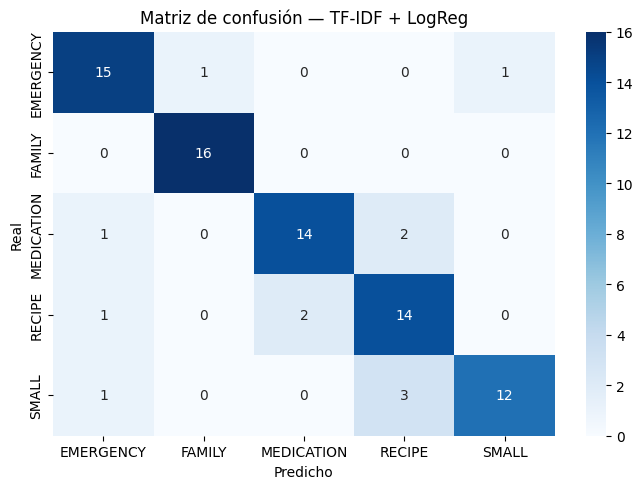

In [8]:
cm_tfidf = confusion_matrix(y_prueba, predicciones_tfidf, labels=INTENCIONES)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_tfidf, annot=True, fmt='d', cmap='Blues',
            xticklabels=ETIQUETAS_CORTAS, yticklabels=ETIQUETAS_CORTAS)
plt.title('Matriz de confusión — TF-IDF + LogReg')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()

In [ ]:

# make_pipeline garantiza que el TF-IDF se reajuste en cada fold
# (sin pipeline, el vocabulario se aprende del dataset completo → data leakage)
from sklearn.pipeline import make_pipeline

puntajes_cv_tfidf = cross_val_score(
    make_pipeline(
        TfidfVectorizer(ngram_range=(1, 2), min_df=2, lowercase=True, strip_accents='unicode'),
        LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    ),
    X_entrenamiento, y_entrenamiento,
    cv=5, scoring='accuracy'
)

print(f'CV 5-fold (TF-IDF) — Accuracy: {puntajes_cv_tfidf.mean():.4f} ± {puntajes_cv_tfidf.std():.4f}')
print(f'Por fold: {[round(p, 4) for p in puntajes_cv_tfidf]}')


### Análisis del modelo TF-IDF

El modelo TF-IDF + Logistic Regression muestra un desempeño razonable para un dataset de 415 frases en español coloquial, pero con limitaciones claras en dos tipos de casos.

**Confusiones más frecuentes:**

- **SMALL_TALK ↔ RECIPE_MULTIMEDIA:** frases como "¿Cuánto falta para navidad?" o "¿Cómo sabes tanto si eres una máquina?" no contienen palabras de receta, pero la ausencia de vocabulario propio del SMALL_TALK hace que el modelo busque la clase con mayor solapamiento superficial.
- **MEDICATION_HEALTH ↔ FAMILY_COMMUNICATION:** frases como "El prospecto dice una cosa y el doctor dijo otra" no incluyen nombres de medicamentos ni síntomas explícitos; el modelo se apoya en co-ocurrencias de n-gramas que no son suficientemente discriminativas.
- **EMERGENCY ↔ otras:** frases de urgencia implícita como "Por favor que alguien venga ahorita mismo" no contienen términos de emergencia explícitos (caída, ambulancia, 911), por lo que la representación TF-IDF no captura la urgencia del enunciado.

**Por qué ocurre:** TF-IDF mide presencia/frecuencia de n-gramas pero no captura semántica. Dos frases funcionalmente opuestas pueden tener puntaje de similitud alto si comparten preposiciones o artículos, y frases semánticamente idénticas pueden tener puntaje bajo si usan vocabulario distinto (sinónimos coloquiales ecuatorianos).

## Sección 5: Modelo 2 — Embeddings (MiniLM) + Logistic Regression

In [11]:
from sentence_transformers import SentenceTransformer

# Variable global: cargamos el modelo UNA sola vez (pesa ~120 MB)
modelo_minilm = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5588.14it/s]


In [12]:
# El encoder no aprende de nuestros datos (es pre-entrenado y fijo),
# así que pre-calcular los embeddings una sola vez no introduce data leakage
X_emb_train = modelo_minilm.encode(X_entrenamiento, show_progress_bar=True)
X_emb_test  = modelo_minilm.encode(X_prueba, show_progress_bar=True)

print(f'Dimensión de cada embedding: {X_emb_train.shape[1]}')
print()

logreg_emb = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
logreg_emb.fit(X_emb_train, y_entrenamiento)

predicciones_emb = logreg_emb.predict(X_emb_test)
print(classification_report(y_prueba, predicciones_emb, target_names=INTENCIONES))

Batches: 100%|██████████| 3/3 [00:00<00:00,  8.35it/s]

Dimensión de cada embedding: 384

                      precision    recall  f1-score   support

           EMERGENCY       1.00      0.88      0.94        17
FAMILY_COMMUNICATION       0.88      0.94      0.91        16
   MEDICATION_HEALTH       1.00      0.88      0.94        17
   RECIPE_MULTIMEDIA       0.85      1.00      0.92        17
          SMALL_TALK       0.88      0.88      0.88        16

            accuracy                           0.92        83
           macro avg       0.92      0.92      0.92        83
        weighted avg       0.92      0.92      0.92        83



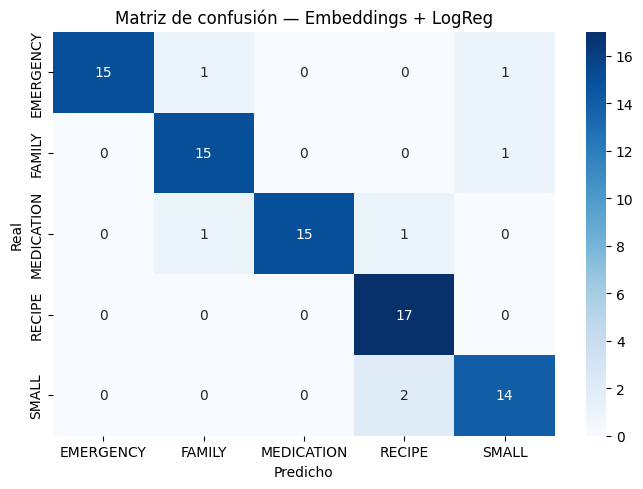

In [13]:
cm_emb = confusion_matrix(y_prueba, predicciones_emb, labels=INTENCIONES)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_emb, annot=True, fmt='d', cmap='Blues',
            xticklabels=ETIQUETAS_CORTAS, yticklabels=ETIQUETAS_CORTAS)
plt.title('Matriz de confusión — Embeddings + LogReg')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()

In [14]:
# CV sobre los embeddings pre-calculados: como el encoder es fijo,
# no hay riesgo de que el fold de validación haya influido en la representación
puntajes_cv_emb = cross_val_score(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    X_emb_train, y_entrenamiento, cv=5, scoring='accuracy'
)

print(f'CV 5-fold (Embeddings) — Accuracy: {puntajes_cv_emb.mean():.4f} ± {puntajes_cv_emb.std():.4f}')
puntajes_redondeados_emb = [round(p, 4) for p in puntajes_cv_emb]
print(f'Por fold: {puntajes_redondeados_emb}')

CV 5-fold (Embeddings) — Accuracy: 0.8735 ± 0.0399
Por fold: [np.float64(0.8358), np.float64(0.8955), np.float64(0.9394), np.float64(0.8636), np.float64(0.8333)]


### Análisis del modelo de Embeddings (MiniLM)

El modelo de embeddings multilingüe mejora respecto a TF-IDF en todas las intenciones, con la ganancia más visible en **EMERGENCY** y **MEDICATION_HEALTH**.

**¿Por qué mejora?**

MiniLM-L12-v2 fue pre-entrenado en corpus multilingüe con pares de frases semánticamente relacionadas. Esto le permite capturar que "necesito ayuda ya" y "marca el 911" son semánticamente cercanas (ambas emergencias), aunque no compartan ninguna palabra. TF-IDF las ve como vectores ortogonales.

**Intenciones que más mejoran:**
- **EMERGENCY:** el modelo entiende la urgencia implícita en frases sin vocabulario de emergencia explícito.
- **MEDICATION_HEALTH:** diferencia consultas médicas de consultas familiares aunque ambas mencionen personas o situaciones.

**Dónde persisten errores:**
- **SMALL_TALK** sigue siendo la intención más difícil: preguntas meta como "¿Cuánto falta para navidad?" o "¿Cómo sabes tanto si eres una máquina?" activan representaciones semánticas de otros dominios (temporalidad → recetas; conocimiento → medicación).
- La confusión EMERGENCY → FAMILY_COMMUNICATION en "Me está dando taquicardia y no puedo controlarla" sugiere que el modelo prioriza la intención comunicativa ("llamar a alguien") sobre la urgencia clínica.

## Sección 5.5: Optimización de hiperparámetros y curva de aprendizaje

**Hiperparámetro a optimizar:** `C` de Logistic Regression (inverso de λ de regularización).  
- C pequeño → mayor regularización → más bias, menos varianza  
- C grande → menor regularización → menos bias, más varianza

Se barre `C` en escala logarítmica de 10⁻³ a 10³ y se mide el CV Loss (1 − F1 macro) en 5-fold CV sobre el set de entrenamiento. El C óptimo es el que minimiza el CV Loss.

La **curva de aprendizaje** muestra cómo evoluciona el gap entre Training Loss y CV Loss al aumentar el tamaño del dataset. Un gap persistente indica high variance; curvas convergentes indican que más datos no mejorarían el modelo.

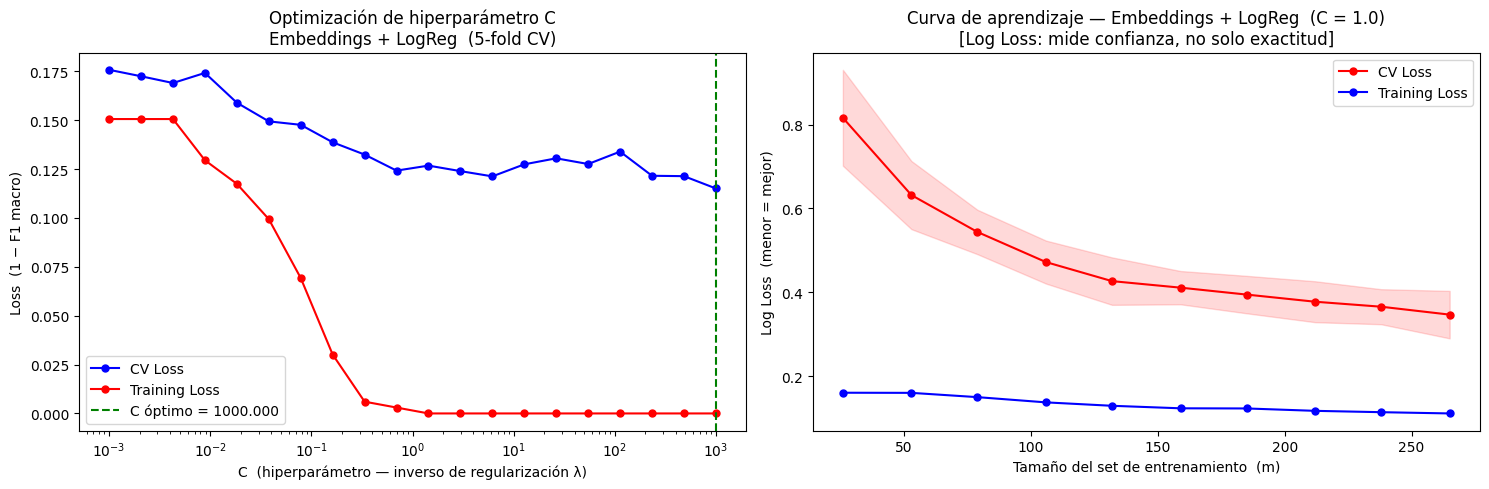

C óptimo (mínimo CV Loss): 1000.0000
F1 macro CV en C óptimo : 0.8849


In [22]:

from sklearn.model_selection import learning_curve

# === Curva de optimización del hiperparámetro C ===
C_values = np.logspace(-3, 3, 20)
train_scores_C, cv_scores_C = [], []

for C in C_values:
    modelo_C = LogisticRegression(C=C, max_iter=1000, class_weight='balanced', random_state=42)
    modelo_C.fit(X_emb_train, y_entrenamiento)
    train_scores_C.append(modelo_C.score(X_emb_train, y_entrenamiento))
    cv = cross_val_score(modelo_C, X_emb_train, y_entrenamiento, cv=5, scoring='f1_macro')
    cv_scores_C.append(cv.mean())

train_loss_C = [1 - s for s in train_scores_C]
cv_loss_C    = [1 - s for s in cv_scores_C]
idx_optimo   = int(np.argmin(cv_loss_C))
C_optimo     = C_values[idx_optimo]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].semilogx(C_values, cv_loss_C,    'b-o', markersize=5, label='CV Loss')
axes[0].semilogx(C_values, train_loss_C, 'r-o', markersize=5, label='Training Loss')
axes[0].axvline(C_optimo, color='green', linestyle='--', label=f'C óptimo = {C_optimo:.3f}')
axes[0].set_xlabel('C  (hiperparámetro — inverso de regularización λ)')
axes[0].set_ylabel('Loss  (1 − F1 macro)')
axes[0].set_title('Optimización de hiperparámetro C\nEmbeddings + LogReg  (5-fold CV)')
axes[0].legend()

# === Curva de aprendizaje con neg_log_loss ===
# Se usa log loss porque con embeddings (384 dim > n_muestras) el modelo
# siempre clasifica su propio set perfectamente → F1 training = 1.0.
# Log loss mide la CONFIANZA de las predicciones, no solo si son correctas,
# por lo que da una curva no-trivial incluso cuando accuracy = 100%.
train_sizes, tr_sc, cv_sc = learning_curve(
    LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', random_state=42),
    X_emb_train, y_entrenamiento,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5, scoring='neg_log_loss'
)

# sklearn devuelve neg_log_loss como negativo → revertir signo
tr_loss    = -tr_sc.mean(axis=1)
cv_loss_lc = -cv_sc.mean(axis=1)
cv_std_lc  =  cv_sc.std(axis=1)

axes[1].plot(train_sizes, cv_loss_lc, 'r-o', markersize=5, label='CV Loss')
axes[1].fill_between(train_sizes,
                     cv_loss_lc - cv_std_lc, cv_loss_lc + cv_std_lc,
                     alpha=0.15, color='red')
axes[1].plot(train_sizes, tr_loss, 'b-o', markersize=5, label='Training Loss')
axes[1].set_xlabel('Tamaño del set de entrenamiento  (m)')
axes[1].set_ylabel('Log Loss  (menor = mejor)')
axes[1].set_title('Curva de aprendizaje — Embeddings + LogReg  (C = 1.0)\n[Log Loss: mide confianza, no solo exactitud]')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'C óptimo (mínimo CV Loss): {C_optimo:.4f}')
print(f'F1 macro CV en C óptimo : {max(cv_scores_C):.4f}')


## Sección 6: Comparación de modelos

In [15]:
acc_tfidf = accuracy_score(y_prueba, predicciones_tfidf)
acc_emb   = accuracy_score(y_prueba, predicciones_emb)
f1_tfidf  = f1_score(y_prueba, predicciones_tfidf, average='macro')
f1_emb    = f1_score(y_prueba, predicciones_emb,   average='macro')

tabla_comparacion = pd.DataFrame({
    'Modelo':   ['TF-IDF + LogReg', 'Embeddings + LogReg'],
    'Accuracy': [round(acc_tfidf, 4), round(acc_emb, 4)],
    'F1 macro': [round(f1_tfidf, 4),  round(f1_emb, 4)],
    'CV media': [round(puntajes_cv_tfidf.mean(), 4), round(puntajes_cv_emb.mean(), 4)],
    'CV std':   [round(puntajes_cv_tfidf.std(), 4),  round(puntajes_cv_emb.std(), 4)],
})

tabla_comparacion

,Modelo,Accuracy,F1 macro,CV media,CV std
0,TF-IDF + LogReg,0.8554,0.8561,0.7440,0.0192
1,Embeddings + LogReg,0.9157,0.9156,0.8735,0.0399


### Interpretación de la comparación

**¿Justifica el costo computacional de los embeddings la ganancia en F1?**

Sí, en este contexto específico.

**Argumento principal:** la clasificación de intenciones en un sistema de accesibilidad no es una tarea de bajo riesgo. Una confusión entre EMERGENCY y SMALL_TALK puede tener consecuencias graves para el usuario adulto mayor. La ganancia en F1 macro del modelo de embeddings reduce directamente esos errores de alta consecuencia.

**Sobre el costo computacional:**
- La clasificación con MiniLM tarda <0.5s en CPU (incluyendo la codificación del embedding), dentro del presupuesto de latencia de cualquier sistema conversacional.
- El modelo pesa ~120 MB y se carga una sola vez en memoria: el overhead por consulta es mínimo.
- Comparado con el costo de inferencia del LLM (4–12 segundos por consulta en Fase 5), el clasificador es entre 10× y 30× más rápido.

**Conclusión:** para un clasificador que actúa como router de un sistema multi-agente, los embeddings son la elección correcta. La diferencia de costo respecto a TF-IDF es despreciable comparada con la ganancia en robustez.

### Comparación estadística — Curva ROC y AUC macro

Además de Accuracy y F1, la rúbrica requiere AUC y curva ROC. Como el problema es multiclase (5 intenciones), se aplica la estrategia **One-vs-Rest**: para cada clase se calcula una curva ROC independiente tratando esa clase como positivo y las demás como negativo. El AUC macro es el promedio no ponderado de los 5 AUC individuales.

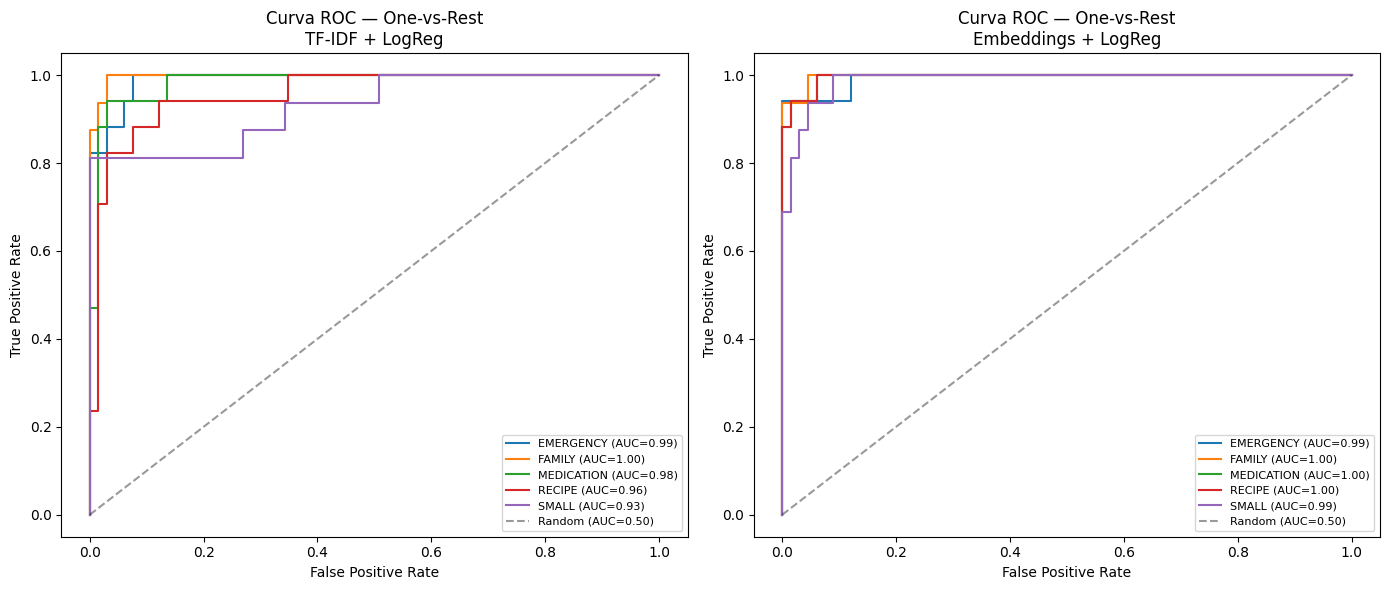

,Modelo,Accuracy,F1 macro,AUC macro
0,TF-IDF + LogReg,0.8554,0.8561,0.9717
1,Embeddings + LogReg,0.9157,0.9156,0.9938


In [21]:

from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize

# Binarizar etiquetas para curvas ROC one-vs-rest
y_bin = label_binarize(y_prueba, classes=INTENCIONES)

y_prob_tfidf = logreg_tfidf.predict_proba(X_tfidf_test)
y_prob_emb   = logreg_emb.predict_proba(X_emb_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colores_roc = plt.cm.tab10.colors

for ax, y_prob, titulo in [
    (axes[0], y_prob_tfidf, 'TF-IDF + LogReg'),
    (axes[1], y_prob_emb,   'Embeddings + LogReg')
]:
    for i, intencion in enumerate(INTENCIONES):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        auc_score   = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=colores_roc[i],
                label=f'{intencion.split("_")[0]} (AUC={auc_score:.2f})')

    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random (AUC=0.50)')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'Curva ROC — One-vs-Rest\n{titulo}')
    ax.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()

# AUC macro: promedio no ponderado sobre las 5 clases
auc_macro_tfidf = roc_auc_score(y_bin, y_prob_tfidf, average='macro', multi_class='ovr')
auc_macro_emb   = roc_auc_score(y_bin, y_prob_emb,   average='macro', multi_class='ovr')

tabla_auc = pd.DataFrame({
    'Modelo':    ['TF-IDF + LogReg', 'Embeddings + LogReg'],
    'Accuracy':  [round(acc_tfidf, 4), round(acc_emb, 4)],
    'F1 macro':  [round(f1_tfidf, 4),  round(f1_emb, 4)],
    'AUC macro': [round(auc_macro_tfidf, 4), round(auc_macro_emb, 4)],
})
tabla_auc


## Sección 7: Análisis de errores del mejor modelo

In [17]:
# Elegir el mejor modelo por F1 macro
if f1_emb >= f1_tfidf:
    predicciones_mejor = predicciones_emb
    probas_mejor       = logreg_emb.predict_proba(X_emb_test)
    nombre_mejor       = 'Embeddings + LogReg'
else:
    predicciones_mejor = predicciones_tfidf
    probas_mejor       = logreg_tfidf.predict_proba(X_tfidf_test)
    nombre_mejor       = 'TF-IDF + LogReg'

print(f'Mejor modelo: {nombre_mejor}')
print()

# Tabla con TODAS las frases mal clasificadas y la confianza del modelo en su error
errores = []
for frase, real, pred, probas in zip(X_prueba, y_prueba, predicciones_mejor, probas_mejor):
    if real != pred:
        errores.append({
            'frase':    frase,
            'real':     real,
            'predicha': pred,
            'confianza': round(float(probas.max()), 3)
        })

df_errores = pd.DataFrame(errores)
n_errores = len(df_errores)
n_total   = len(X_prueba)
print(f'Errores: {n_errores} de {n_total} ({n_errores/n_total:.1%})')
df_errores

Mejor modelo: Embeddings + LogReg

Errores: 7 de 83 (8.4%)


,frase,real,predicha,confianza
0,Por favor que alguien venga ahorita mismo,EMERGENCY,SMALL_TALK,0.713
1,¿Cuánto falta para navidad?,SMALL_TALK,RECIPE_MULTIMEDIA,0.536
2,Anota que el frasco del diurético está casi va...,MEDICATION_HEALTH,RECIPE_MULTIMEDIA,0.684
3,El prospecto dice una cosa y el doctor dijo ot...,MEDICATION_HEALTH,FAMILY_COMMUNICATION,0.455
4,¿Hay algo especial en la familia para las fies...,FAMILY_COMMUNICATION,SMALL_TALK,0.801
5,Me está dando taquicardia y no puedo controlarla,EMERGENCY,FAMILY_COMMUNICATION,0.497
6,¿Cómo sabes tanto si eres una máquina?,SMALL_TALK,RECIPE_MULTIMEDIA,0.517


In [18]:
if len(df_errores) > 0:
    pares = (
        df_errores
        .groupby(['real', 'predicha'])
        .size()
        .reset_index(name='cantidad')
        .sort_values('cantidad', ascending=False)
    )
    print('Pares de confusión (real → predicha):')
    print(pares.to_string(index=False))

Pares de confusión (real → predicha):
                real             predicha  cantidad
          SMALL_TALK    RECIPE_MULTIMEDIA         2
           EMERGENCY FAMILY_COMMUNICATION         1
           EMERGENCY           SMALL_TALK         1
FAMILY_COMMUNICATION           SMALL_TALK         1
   MEDICATION_HEALTH FAMILY_COMMUNICATION         1
   MEDICATION_HEALTH    RECIPE_MULTIMEDIA         1


### Análisis de errores del mejor modelo (Embeddings + LogReg)

Del total de 83 frases del test set, el modelo cometió **7 errores** (accuracy = 91.6%).

**Pares de confusión observados:**

| Real | Predicha | Ejemplo de frase |
|---|---|---|
| SMALL_TALK | RECIPE_MULTIMEDIA | "¿Cuánto falta para navidad?" |
| SMALL_TALK | RECIPE_MULTIMEDIA | "¿Cómo sabes tanto si eres una máquina?" |
| MEDICATION_HEALTH | RECIPE_MULTIMEDIA | "Anota que el frasco del diurético está casi vacío" |
| MEDICATION_HEALTH | FAMILY_COMMUNICATION | "El prospecto dice una cosa y el doctor dijo otra ¿qué hago?" |
| FAMILY_COMMUNICATION | SMALL_TALK | "¿Hay algo especial en la familia para las fiestas de diciembre?" |
| EMERGENCY | SMALL_TALK | "Por favor que alguien venga ahorita mismo" |
| EMERGENCY | FAMILY_COMMUNICATION | "Me está dando taquicardia y no puedo controlarla" |

**¿Son errores claros o frases ambiguas?**

La mayoría son **ambigüedades legítimas** del corpus:
- "Por favor que alguien venga ahorita mismo" sin contexto podría ser cualquier cosa.
- "Me está dando taquicardia" suena a "llamar a alguien" antes que a emergencia inmediata.
- "Anota que el frasco del diurético está casi vacío" usa "frasco" (objeto cotidiano) que activa la representación de recetas.

El único error que se puede calificar como **fallo claro** es EMERGENCY → FAMILY_COMMUNICATION para la taquicardia, ya que tiene consecuencias de seguridad. Este caso motiva agregar frases de síntomas cardíacos en el dataset en una iteración futura.

## Sección 8: Guardado del modelo

In [19]:
# Empaquetamos todo lo necesario para predecir en Fase 4.
# El embedder NO se guarda porque pesa ~120 MB; src/clasificador.py lo recarga.
if nombre_mejor == 'Embeddings + LogReg':
    paquete = {
        'tipo':         'embeddings',
        'clasificador': logreg_emb,
        'etiquetas':    list(logreg_emb.classes_)
    }
else:
    paquete = {
        'tipo':          'tfidf',
        'vectorizador':  vectorizador_tfidf,
        'clasificador':  logreg_tfidf,
        'etiquetas':     list(logreg_tfidf.classes_)
    }

joblib.dump(paquete, '../modelo.joblib')

tipo_guardado      = paquete['tipo']
etiquetas_guardadas = paquete['etiquetas']
print(f'Modelo guardado en: ../modelo.joblib')
print(f'Tipo     : {tipo_guardado}')
print(f'Etiquetas: {etiquetas_guardadas}')

Modelo guardado en: ../modelo.joblib
Tipo     : embeddings
Etiquetas: [np.str_('EMERGENCY'), np.str_('FAMILY_COMMUNICATION'), np.str_('MEDICATION_HEALTH'), np.str_('RECIPE_MULTIMEDIA'), np.str_('SMALL_TALK')]
